# Treasury market

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dbnomics import fetch_series

In [3]:
# Paramétrage des styles utilisés par matplotlib
plt.style.use('default')
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

In [5]:
# Utilities

# Inflation
df = pd.read_csv("Data/USCPI_1774-2024.csv", skiprows=2) 
df["Year"] = df["Year"].astype(int)
df.set_index("Year", inplace=True)
cpi = df["U.S. Consumer Price Index *"]
cpi.index.name = None

def real_price(value,date=None,base=2024):
    if type(value) == list:
        l = []
        for i in value:
            l.append(float(i*cpi[base]/cpi[date]))
        return l
    elif type(value) == type(np.array([])):
        return value*cpi[base]/cpi[date]
    elif type(value) == type(pd.Series([])):
        return value/(cpi/cpi.loc[base])
    else:
        return float(value*cpi[base]/cpi[date])
    
#GDP
df = pd.read_csv("Data/USGDP_1790-2024.csv", skiprows=1, thousands=',')
df = df.set_index('Year')
nominal_gdp = df['Nominal GDP (million of Dollars)']
real_gdp = df['Real GDP (millions of 2017 dollars)']

## According to Flow of Funds data

Code :
* Le .Q à la fin c'est pour donnée Quaterly (et.A pour annuelle).
* FL : pour les niveaux
* Secteur c'est les deux chiffres suivants
* 30611 c'est pour l'instrument (Treasuries)
* 05 pour les "computed series"

Code pour le moment :
* FL143061105.Q : Nonfinancial business (S11) 
* FL153061105.Q : Households and nonprofit organizations (S14+S15)
* FL263061105.Q : Rest of the World (S2)*
* FL383061105.Q : Domestic nonfinancial sectors
* FL403061105.Q : Government-sponsored enterprises (GSEs)
* FL473061105.Q : Credit Unions
* FL513061105.Q : Property-casualty insurance companies*
* FL523061105.Q : Insurance companies (S128)
* FL533061105.Q : Closed-end and exchange-traded funds
* FL543061105.Q : Life insurance companies*
* FL573061105.Q : Private pension funds
* FL583061105.Q : Insurance companies and pension funds (S128+S129) 
* FL593061105.Q : Pension funds (S129)
* FL603061105.Q : Other financial intermediaries except insurance companies, pension funds, financial auxiliaries and captive financial institutions and money lenders (S125)
* FL803061105.Q : Other financial intermediaries except insurance companies and pension funds (S125+S126+S127) 
* FL633061105.Q : Money market funds (S123)
* FL653061105.Q : Mutual funds*
* FL663061105.Q : Security brokers and dealers (S127 ?)
* FL693061105.Q : Non-MMF investment funds (S124)
* FL703061105.Q : Private depository institutions (S122)
* FL713061125.Q : Monetary authority (S121)
* FL783061105.Q : Private depository institutions and money market funds (S122+S123)
* FL793061105.Q : Domestic financial sectors (S12)
* FL893061105.Q : All sectors


\* petite incertitude pcq y'a trois séries possibles sur dbnmics, probablement une erreur

In [ ]:
import dbnomics
import pandas as pd
import matplotlib.pyplot as plt

# Sélection des séries
codes = {
    # volume de Treasuries
    "Nonfinancial business (S11)": "FL143061105.Q",
    "Rest of World (S2)": "FL263061105.Q",
    "Households and non-profit organizations (S14+S15)": "FL153061105.Q",
    "Monetary authority (S121)": "FL713061125.Q",
    "Private Depository Institutions (S122)": "FL703061105.Q",
    "Money Market Funds (S123)": "FL633061105.Q",
    "Mutual Funds (S124)": "FL653061105.Q",
    "Other financial intermediaries except insurance companies and pension funds (S125+S126+S127)" : "FL803061105.Q",
    "Insurance companies (S128)": "FL523061105.Q",
    "Pension Funds (S129)": "FL593061105.Q",
    "Security brokers and dealers": "FL663061105.Q",
    "Closed-end and exchange-traded funds": "FL533061105.Q",
    # les assets totaux
    "Monetary authority (S121) TA": "FL712000095.Q",
    "Private Depository Institutions (S122) TA": "FL702000095.Q",
    "Money Market Funds (S123) TA":"FL634090005.Q",
    "Insurance companies (S128) TA": "FL522000095.Q",
    "Pension Funds (S129) TA": "FL592000005.Q"    
}

# Télécharger et assembler les séries
dfs = []
for label, code in codes.items():
    data = dbnomics.fetch_series(f"FED/Z1/{code}")
    df_temp = data[['period', 'value']].dropna()
    df_temp['period'] = pd.PeriodIndex(df_temp['period'], freq='Q').to_timestamp()
    df_temp = df_temp.set_index('period').rename(columns={'value': label})
    dfs.append(df_temp)

df = pd.concat(dfs, axis=1)

# Télécharger la série "All sectors"
all_sectors = dbnomics.fetch_series("FED/Z1/FL893061105.Q")
all_sectors = all_sectors[['period', 'value']].dropna()
all_sectors['period'] = pd.PeriodIndex(all_sectors['period'], freq='Q').to_timestamp()
all_sectors = all_sectors.set_index('period')['value']

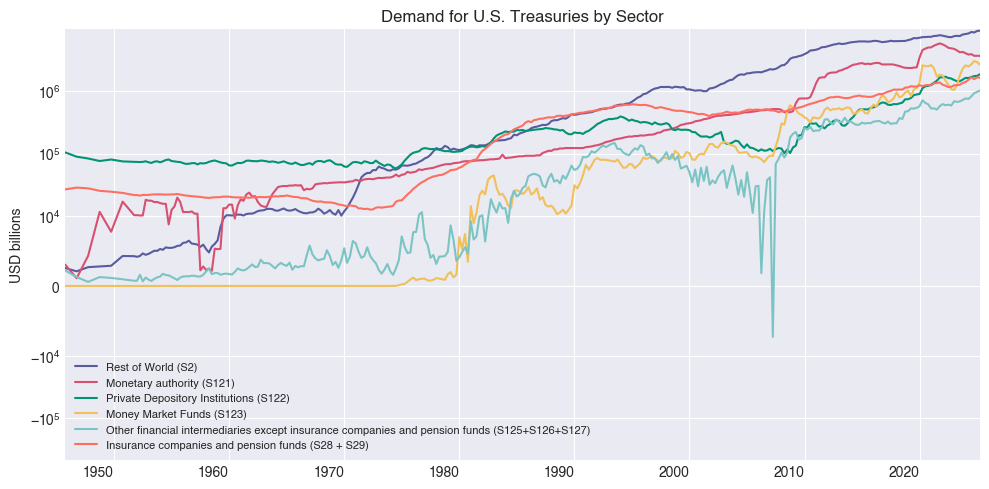

In [5]:
df1 = df.copy()
df1["Insurance companies and pension funds (S28 + S29)"] = df1["Insurance companies (S128)"] + df1["Pension Funds (S129)"]

df1 = df1.drop(columns=["Households and non-profit organizations (S14+S15)",
                        "Mutual Funds (S124)", "Nonfinancial business (S11)",
                        "Insurance companies (S128)",
                        "Pension Funds (S129)",
                        "Security brokers and dealers",
                        "Closed-end and exchange-traded funds"])
df1.index.name = None

#start_date = '1945-01-01'
#end_date = '1991-01-01'
#df1 = df1[(df.index >= start_date) & (df.index <= end_date)]

# Tracer
fig, ax = plt.subplots(figsize=(10, 5))
df1.plot(ax=ax)
ax.set_title("Demand for U.S. Treasuries by Sector")
ax.set_ylabel("USD billions")
#ax.set_yscale('log')
ax.set_yscale('symlog', linthresh=10000)
ax.set_xmargin(0)
plt.xticks(rotation=0)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_21560/2068110210.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = list(plt.cm.get_cmap('Set1').colors[:7])


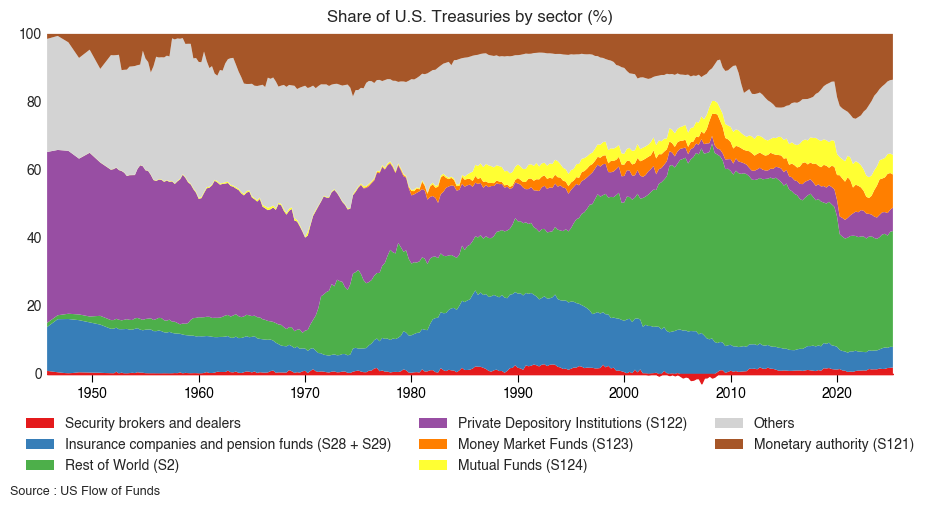

In [ ]:
df_prop = df.div(all_sectors, axis=0)
df_prop = df_prop * 100
df_prop["Insurance companies and pension funds (S28 + S29)"] = df_prop["Insurance companies (S128)"] + df_prop["Pension Funds (S129)"]


# Sélection de quelques séries
selected = ["Security brokers and dealers",
            "Insurance companies and pension funds (S28 + S29)",
            "Rest of World (S2)",
            "Private Depository Institutions (S122)",
            "Money Market Funds (S123)",
            "Mutual Funds (S124)",
            "Monetary authority (S121)",
            ]

neg = df_prop["Security brokers and dealers"].clip(upper=0)
pos = df_prop["Security brokers and dealers"].clip(lower=0)
df_prop["Security brokers and dealers"] = pos

# Calcul de la part "Others"
df_prop = df_prop[selected].copy()
df_prop["Others"] = 100 - df_prop.sum(axis=1)

selected.remove("Monetary authority (S121)")
selected.append("Others")
selected.append("Monetary authority (S121)")
df_prop = df_prop[selected]

colors = list(plt.cm.get_cmap('Set1').colors[:7])        
colors.append('lightgray')
colors[-1], colors[-2] = colors [-2], colors [-1]

# Tracé
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(df_prop.index, df_prop.T, labels=df_prop.columns,colors=colors)
ax.set_xmargin(0)
ax.margins(y=0.01)
ax.set_facecolor('white')
ax.set_title("Share of U.S. Treasuries by sector (%)")
ax.fill_between(df_prop.index, neg, 0, color=colors[0])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# Forcer la spine du bas
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
#ax.spines['bottom'].set_linewidth(1.0)

# Forcer les ticks vers l'extérieur et visibles
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', direction='out', length=6, colors='black', bottom=True, top=False)

# S'assurer que les labels sont visibles
ax.xaxis.set_tick_params(labelcolor='black')

plt.xticks(rotation=0)
fig.text(0.04, -0.0, "Source : US Flow of Funds", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

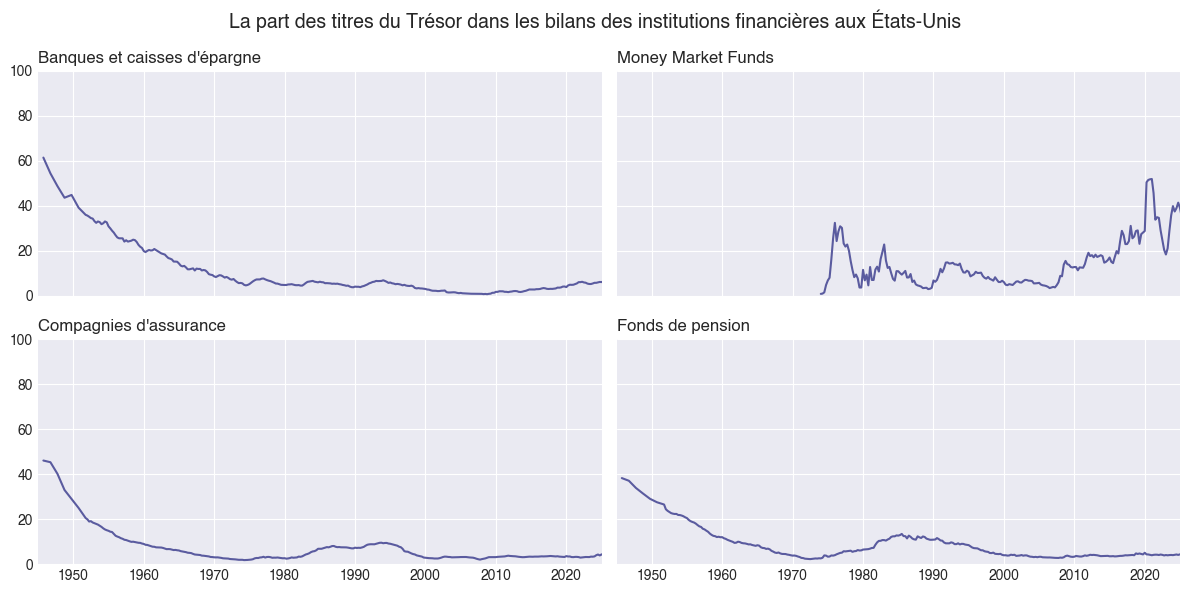

In [ ]:
import dbnomics
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

treasuries = {
    "S122": "FL703061105.Q",
    "S123": "FL633061105.Q",
    "S128": "FL523061105.Q",
    "S129": "FL593061105.Q"
}

totals = {
    "S122": "FL702000095.Q",
    "S123": "FL634090005.Q",
    "S128": "FL522000095.Q",
    "S129": "FL592000005.Q"
}

names = {
    "S122": "Banques et caisses d'épargne",
    "S123": "Money Market Funds",
    "S128": "Compagnies d'assurance",
    "S129": "Fonds de pension"
}

# municipal :
# banques et autres institutions de dépot : FL703062005.Q
# assurances : FL523062005.Q
# fonds de pension FL593062045.Q

# Agency- and GSE-Backed securities
# banque et autres dépot : FL703061705.Q
# assurances FL523061705.Q
# fonds de pension FL593061705.Q

def fetch(code):
    d = dbnomics.fetch_series(f"FED/Z1/{code}")
    d = d[['period','value']].dropna()
    d['period'] = pd.PeriodIndex(d['period'], freq='Q').to_timestamp()
    return d.set_index('period')['value']

ratios = {}
for s in treasuries:
    tr = fetch(treasuries[s])
    ta = fetch(totals[s])
    ratios[s] = (tr / ta * 100).dropna()

xmin = pd.Timestamp("1945-01-01")
xmax = pd.Timestamp("2025-01-01")

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, (ax, s) in enumerate(zip(axes, ratios)):
    ax.plot(ratios[s].index, ratios[s].values)
    ax.set_title(f"{names[s]}", loc="left")
    ax.set_ylim(0, 100)
    ax.set_xlim(xmin, xmax)

    if i in [0, 1]:
        ax.set_xticklabels([])

    if i in [1, 3]:
        ax.set_yticklabels([])

fig.suptitle("La part des titres du Trésor dans les bilans des institutions financières aux États-Unis", fontsize=14)
plt.tight_layout()
plt.show()


In [42]:
import dbnomics
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# --- Codes ---
treasuries = {
    "S122": "FL703061105.Q",
    "S123": "FL633061105.Q",
    "S128": "FL523061105.Q",
    "S129": "FL593061105.Q"
}

totals = {
    "S122": "FL702000095.Q",
    "S123": "FL634090005.Q",
    "S128": "FL522000095.Q",
    "S129": "FL592000005.Q"
}

munis = {
    "S122": "FL703062005.Q",
    "S123": None,
    "S128": "FL523062005.Q",
    "S129": "FL593062045.Q"
}

agency = {
    "S122": "FL703061705.Q",
    "S123": None,
    "S128": "FL523061705.Q",
    "S129": "FL593061705.Q"
}

names = {
    "S122": "Banques et caisses d'épargne",
    "S123": "Money Market Funds",
    "S128": "Compagnies d'assurance",
    "S129": "Fonds de pension"
}

# --- Fonction de téléchargement ---
def fetch(code):
    if code is None:
        return None
    df = dbnomics.fetch_series(f"FED/Z1/{code}")
    df = df[['period','value']].dropna()
    df['period'] = pd.PeriodIndex(df['period'], freq='Q').to_timestamp()
    return df.set_index('period')['value']

# --- Télécharger toutes les séries ---
data = {}
for s in ["S122","S123","S128","S129"]:
    data[s] = {}
    data[s]['treasuries'] = fetch(treasuries[s])
    data[s]['total'] = fetch(totals[s])
    data[s]['munis'] = fetch(munis[s])
    data[s]['agency'] = fetch(agency[s])

# --- Calculer les ratios ---
ratios = {}
for s in data:
    tr = data[s]['treasuries']
    ta = data[s]['total']
    mn = data[s]['munis'] if data[s]['munis'] is not None else pd.Series(0, index=tr.index)
    ag = data[s]['agency'] if data[s]['agency'] is not None else pd.Series(0, index=tr.index)

    # union des index
    all_idx = tr.index.union(ta.index).union(mn.index).union(ag.index)
    tr = tr.reindex(all_idx)
    ta = ta.reindex(all_idx)
    mn = mn.reindex(all_idx, fill_value=0)
    ag = ag.reindex(all_idx, fill_value=0)

    ratios[s] = pd.DataFrame({
        'Treasuries': tr / ta * 100,
        'Municipals': mn / ta * 100,
        'Agency & GSE': ag / ta * 100
    }, index=all_idx)


/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_14617/2710359370.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


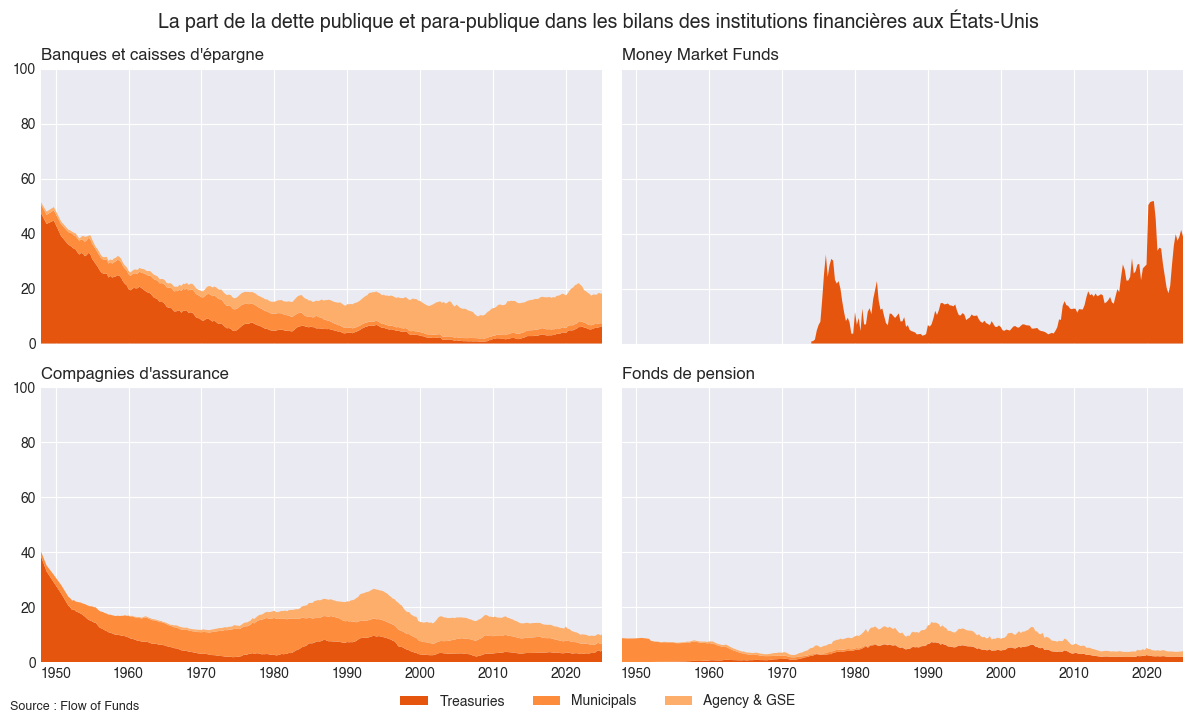

In [ ]:
# --- Tracé ---
cmap = cm.get_cmap('tab20c')
colors = [cmap(4), cmap(5), cmap(6)]

xmin = pd.Timestamp("1948-01-01")
xmax = pd.Timestamp("2025-01-01")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for i, s in enumerate(["S122","S123","S128","S129"]):
    ax = axes[i]
    df_plot = ratios[s]
    ax.stackplot(df_plot.index, df_plot.T.values, colors=colors)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 100)
    ax.set_title(names[s], loc="left")
    
    if i < 2:
        ax.set_xticklabels([])
    if i % 2 == 1:
        ax.set_yticklabels([])

# Légende globale
fig.legend(['Treasuries','Municipals','Agency & GSE'], loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.02))
fig.text(0.01, -0.02, "Source : Flow of Funds", ha="left", fontsize=9)
fig.suptitle("La dette publique et para-publique dans les bilans des institutions financières aux États-Unis", fontsize=14)

plt.tight_layout()
plt.show()

/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_14617/748618695.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


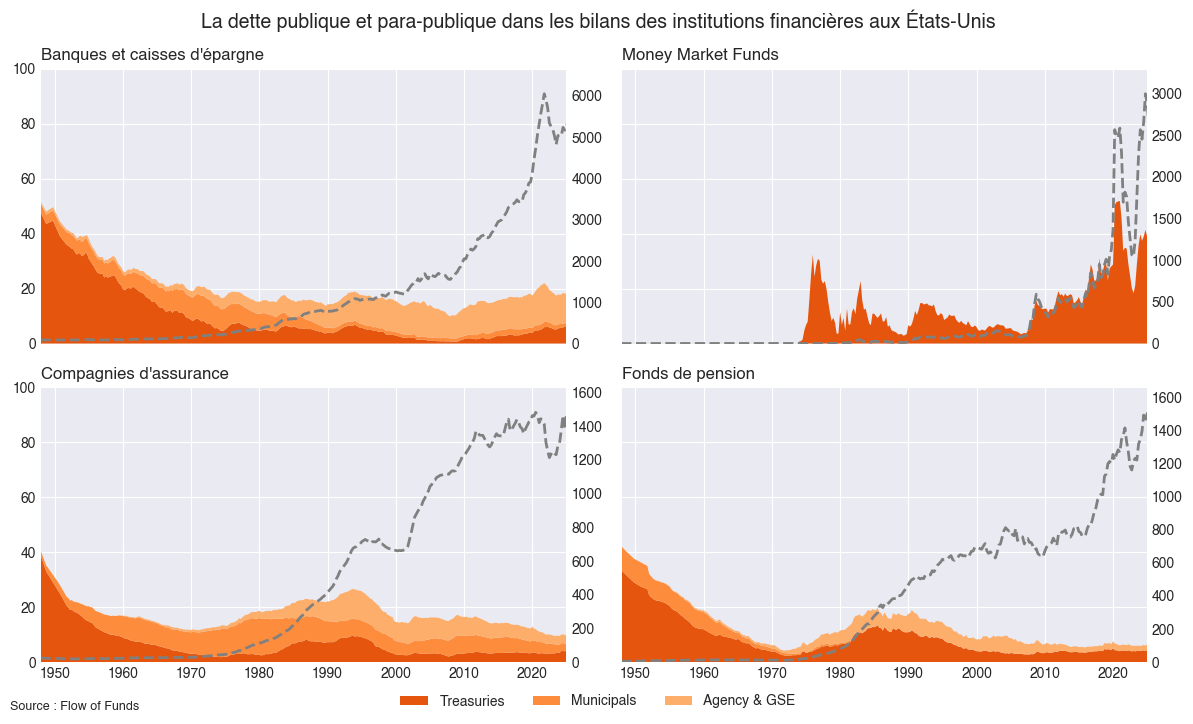

In [47]:
cmap = cm.get_cmap('tab20c')
colors = [cmap(4), cmap(5), cmap(6)]

xmin = pd.Timestamp("1948-01-01")
xmax = pd.Timestamp("2025-01-01")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for i, s in enumerate(["S122","S123","S128","S129"]):
    ax = axes[i]
    df_plot = ratios[s]

    # Stackplot en %
    ax.stackplot(df_plot.index, df_plot.T.values, colors=colors)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 100)
    ax.set_title(names[s], loc="left")

    if i < 2:
        ax.set_xticklabels([])
    if i % 2 == 1:
        ax.set_yticklabels([])

    # Axe secondaire pour le volume total
    ax2 = ax.twinx()
    tr = data[s]['treasuries'].reindex(df_plot.index, fill_value=0)
    mn = data[s]['munis'].reindex(df_plot.index, fill_value=0) if data[s]['munis'] is not None else pd.Series(0, index=df_plot.index)
    ag = data[s]['agency'].reindex(df_plot.index, fill_value=0) if data[s]['agency'] is not None else pd.Series(0, index=df_plot.index)
    total_volume = (tr + mn + ag)/ 1e3
    line_volume, = ax2.plot(df_plot.index, total_volume, color='grey', linewidth=2, linestyle='--', label='Volume total')
    ax2.set_ylim(0, total_volume.max()*1.1)
    ax2.grid(False)  # supprime la grille pour l'axe droit


fig.legend(['Treasuries','Municipals','Agency & GSE'], loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.02))
fig.text(0.01, -0.02, "Source : Flow of Funds", ha="left", fontsize=9)
fig.suptitle("La dette publique et para-publique dans les bilans des institutions financières aux États-Unis", fontsize=14)

plt.tight_layout()
plt.show()


## IMF Historical Public Debt Database

In [7]:
df = fetch_series("IMF/HPDD/A.US.GGXWDG_GDP")
df = df[["original_period", "original_value"]]
df["original_period"] = pd.to_numeric(df["original_period"], errors='coerce')
df["original_value"] = pd.to_numeric(df["original_value"], errors='coerce')
df = df.dropna(subset=["original_period", "original_value"])
series = df.set_index("original_period")["original_value"]
series.index.name = None

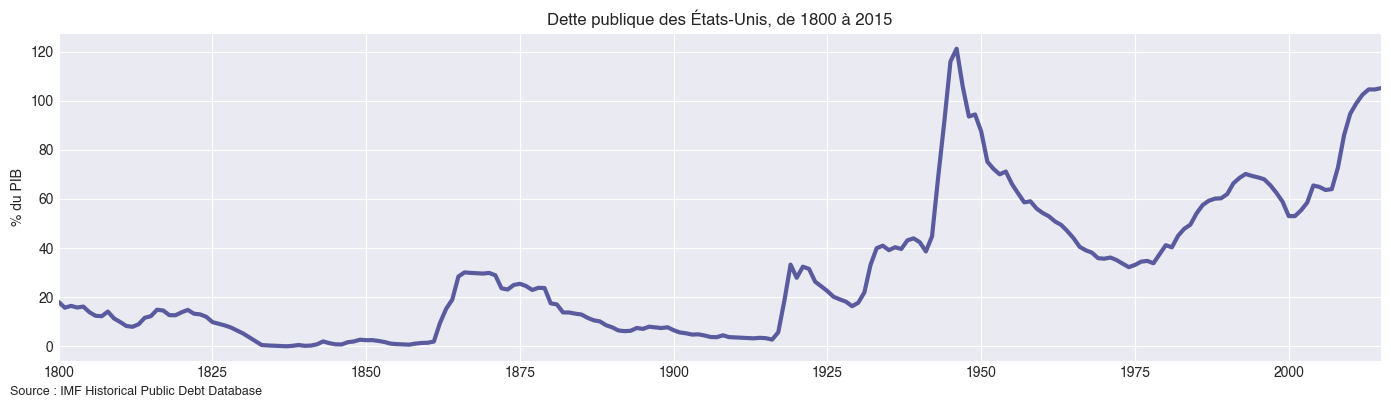

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series.index, series.values, linewidth=3)
ax.set_title("Dette publique des États-Unis, de 1800 à 2015")
ax.set_ylabel("% du PIB")
ax.set_xmargin(0)

fig.text(0.01, -0.0, "Source : IMF Historical Public Debt Database", ha="left", fontsize=9)
plt.tight_layout()
plt.show()

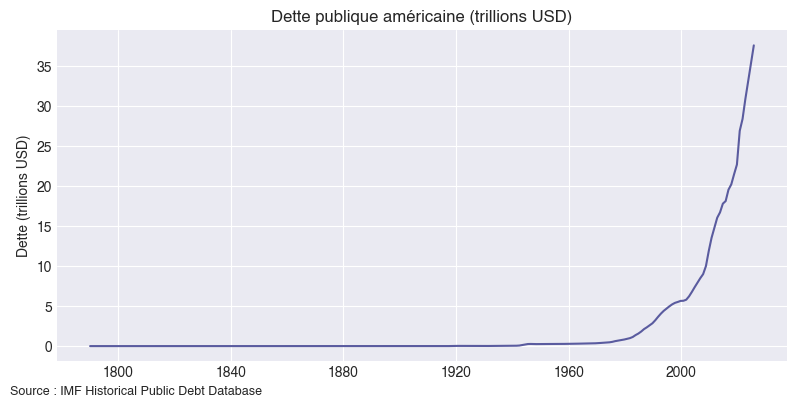

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# lecture du CSV
df = pd.read_csv("Data/HstDebt_17900101_20250930.csv")

# conversion de la colonne date
df["Record Date"] = pd.to_datetime(df["Record Date"])
df = df.sort_values("Record Date")  # tri par date
# création du graphique
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["Record Date"], df["Debt Outstanding Amount"] / 1e12)
ax.set_title("Dette publique américaine (trillions USD)")
ax.set_ylabel("Dette (trillions USD)")
#ax.set_yscale('log')
fig.text(0.01, -0.0, "Source : IMF Historical Public Debt Database", ha="left", fontsize=9)
plt.tight_layout()
plt.show()


In [10]:
df = pd.read_csv("Data/HstDebt_17900101_20250930.csv")
df = df.sort_values("Record Date")
df["Record Date"] = pd.to_datetime(df["Record Date"], errors="coerce")
df["Record Date"] = df["Record Date"].dt.year.astype("Int64")
df["Debt Outstanding Amount"] = df["Debt Outstanding Amount"] / 1e12

series2 = df.set_index("Record Date")["Debt Outstanding Amount"]
series2.index.name = None

series2.head()

1790    0.000071
1791    0.000075
1792    0.000077
1793    0.000080
1794    0.000078
Name: Debt Outstanding Amount, dtype: float64

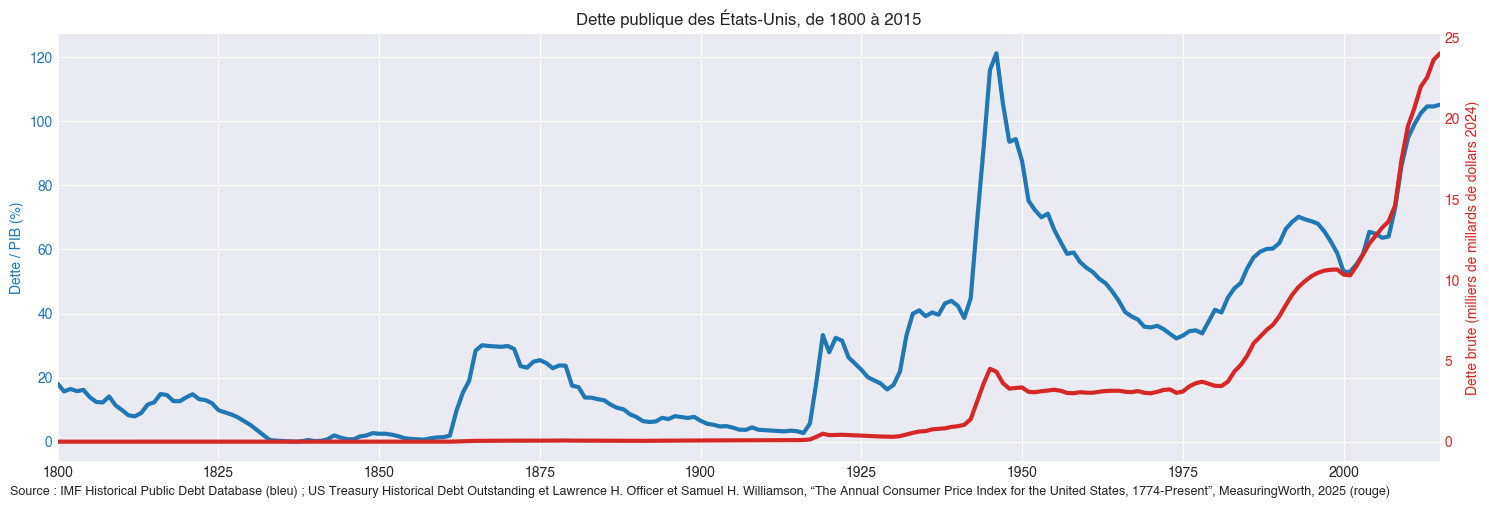

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import LinearLocator

s1 = series
s2 = real_price(series2)

s1 = s1.groupby(s1.index).mean()
s2 = s2.groupby(s2.index).mean()

# fusionner sur l’année commune
df = pd.DataFrame({
    "Debt_Pct_GDP": s1,
    "Debt_Absolute": s2
}).dropna()

# plot
fig, ax1 = plt.subplots(figsize=(15, 5))

# axe gauche : %
ax1.plot(df.index, df["Debt_Pct_GDP"], color="tab:blue", label="Dette / PIB (%)", linewidth=3)
ax1.set_ylabel("Dette / PIB (%)", color="tab:blue")
ax1.set_xmargin(0)
ax1.tick_params(axis="y", labelcolor="tab:blue")

# axe droit : USD log
ax2 = ax1.twinx()
ax2.plot(df.index, df["Debt_Absolute"], color="tab:red", label="Dette brute (USD)", linewidth=3)
#ax2.set_yscale("log")
ax2.set_ylabel("Dette brute (milliers de millards de dollars 2024)", color="tab:red")
ax2.set_xmargin(0)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax2.grid(False)
ax1.set_title("Dette publique des États-Unis, de 1800 à 2015")

fig.text(0.01, -0.0, "Source : IMF Historical Public Debt Database (bleu) ; US Treasury Historical Debt Outstanding et Lawrence H. Officer et Samuel H. Williamson, “The Annual Consumer Price Index for the United States, 1774-Present”, MeasuringWorth, 2025 (rouge)", ha="left", fontsize=9)
fig.tight_layout()
plt.show()


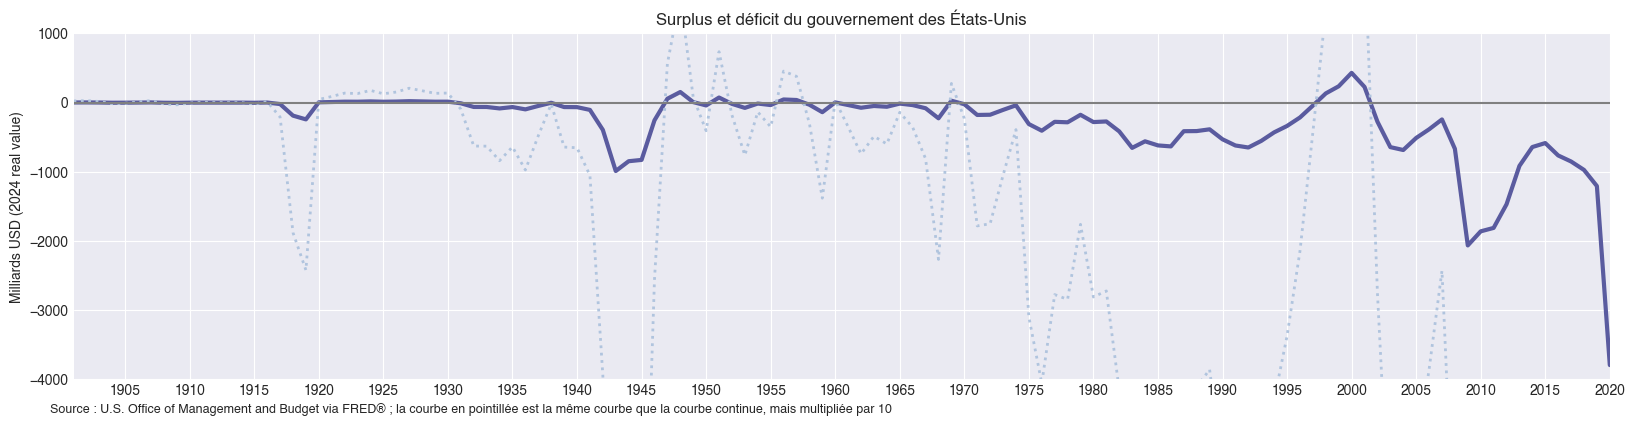

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# lecture du CSV
df = pd.read_csv("Data/FYFSD.csv")

# conversion de la colonne date
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df.sort_values("observation_date")  # tri par date
s = df.set_index(pd.to_datetime(df["observation_date"]).dt.year)["FYFSD"]
s.index.name = None
s = real_price(s)
s = s/1000

# création du graphique
fig, ax = plt.subplots(figsize=(16, 4))
plt.tight_layout()
s.loc[1900:2020].plot(ax=ax, linewidth=3)
s_zoom = s*10
s_zoom.loc[1900:2020].plot(ax=ax, linewidth=2, linestyle='dotted', color='lightsteelblue')
ax.set_title("Surplus et déficit du gouvernement des États-Unis")
ax.set_ylabel("Milliards USD (2024 real value)")
ax.set_xmargin(0)
ax.xaxis.set_major_locator(MaxNLocator(nbins=28)) 
ax.set_ylim(bottom=-4000, top=1000)

fig.text(0.01, -0.0, "Source : U.S. Office of Management and Budget via FRED® ; la courbe en pointillée est la même courbe que la courbe continue, mais multipliée par 10", ha="left", fontsize=9)
plt.axhline(0, color='gray')
plt.show()


/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_28809/374072074.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([abs(int(tick)) for tick in ax.get_yticks()])


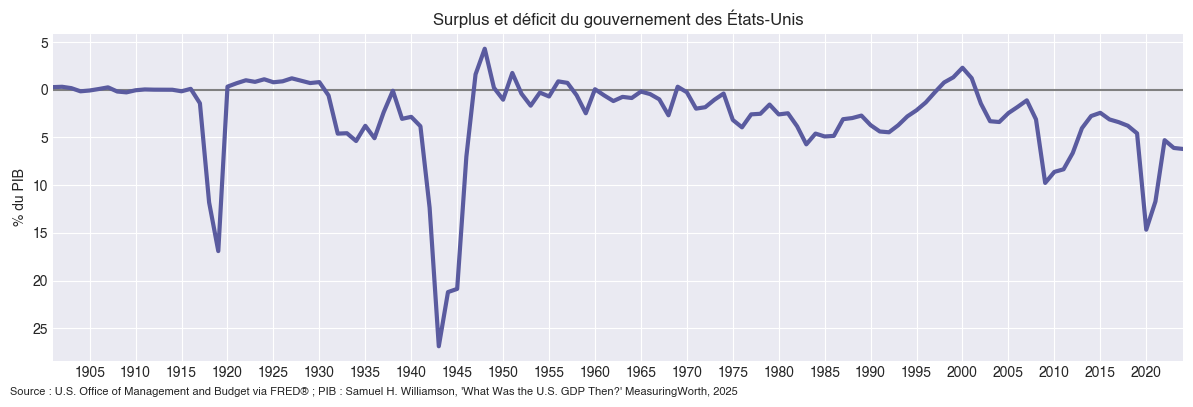

In [14]:
df = pd.read_csv("Data/FYFSD.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df.sort_values("observation_date")  # tri par date
s = df.set_index(pd.to_datetime(df["observation_date"]).dt.year)["FYFSD"]
s.index.name = None
s = 100*s/nominal_gdp

# création du graphique
fig, ax = plt.subplots(figsize=(12, 4))
plt.axhline(0, color='gray')

s.plot(ax=ax, linewidth=3)
ax.set_title("Surplus et déficit du gouvernement des États-Unis")
ax.set_ylabel("% du PIB")
ax.set_xmargin(0)
ax.xaxis.set_major_locator(MaxNLocator(nbins=28))
ax.set_yticklabels([abs(int(tick)) for tick in ax.get_yticks()])

"""
ax.annotate(
    "Budget restreint et \néquilibré",
    xy=(1909, -1),
    xytext=(1902, -7),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Première Guerre mondiale",
    xy=(1917, -10),
    xytext=(1904, -24),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=-0.3",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Austérité des\nannées 1920",
    xy=(1925, -0.5),
    xytext=(1922, -13),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.1",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Crise des\nannées 1930",
    xy=(1933, -6),
    xytext=(1924, -23),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.3",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Seconde Guerre mondiale",
    xy=(1946, -20),
    xytext=(1950, -26),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.1",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Budget important\n et (relativement) équilibré",
    xy=(1959, -5),
    xytext=(1952, -16),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.1",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Début du déficit permanent",
    xy=(1975, -4),
    xytext=(1970, -18),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=-0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Début de la consolidation fiscale,\naustérié sous Clinton",
    xy=(1992, -5),
    xytext=(1982, -13),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Crise de 2008",
    xy=(2009, -11),
    xytext=(2000, -22),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Covid",
    xy=(2020, -15),
    xytext=(2018, -20),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)
"""

fig.text(0.01, -0.0, "Source : U.S. Office of Management and Budget via FRED® ; PIB : Samuel H. Williamson, 'What Was the U.S. GDP Then?' MeasuringWorth, 2025", ha="left", fontsize=8)

plt.tight_layout()
plt.show()


## Primary Dealer Statistics (FRBNY)

Disponibles à https://www.newyorkfed.org/markets/counterparties/primary-dealers-statistics
Noms des séries dans le .csv :
* Jan1998 to June2001
  * Net Position, US Gov
    * T-bills : PDPUSGTBNOP
    * Coupon, <=5 years : PDPUSGCS5LNOP
    * Coupon, > years : PDPUSGCS5MNOP
  * Transaction, US Gov
    * By Custumer with Inter-Dealer Broker : PDCUSGIDBOT
    * By Custumer with Others : PDCUSGOOT
    * By Security, T-bills : PDSUSGTBOT
    * By Security, Coupon, <= 5 years : PDSUSGCS5LOT
    * By Security, Coupon, > 5 years : PDSUSGCS5MOT
  * Financing
    * Securities In
      * Reverse Repurchase Agreements O/N and continuing : PDFRRPTA
      * Reverse Repurchase Agreements term : PDFRRPOC
      * Securities Borrowed O/N : PDFSBTA
      * Securities Borrowed term : PDFSBOC
      * Securities Received as Pledge O/N : PDFSRPTA
      * Securities Received as Pledge term : PDFSRPOC
    * Securities Out
      * Repurchase Agreements O/N : PDFRPTA
      * Repurchase Agreements term : PDFRPOC
      * Securities Lent O/N : PDFSLTA
      * Securities Lent term : PDFSLOC
      * Securities Pledged O/N : PDFSPTA
      * Securities Pledged term : PDFSPOC
      * Collateralized Loans : PDFCLT
* Jan2001 to March2013
  * Net Position, US Gov
    * T-bills : SAME (PDPUSGTBNOP)
    * Coupon <= 3 years : PDPUSGCS36NOP * Semble il y avoir une erreur
    * Coupon <= 6 years : PDPUSGCS611NOP
    * Coupon <= 11 years : PDPUSGCSM11NOP
    * Coupon > 11 years : PDPUSGCS3LNOP
  * Transaction, US Gov
    * By Security, T-bills : SAME (PDSUSGTBOT)
    * By Security, Coupon <= 3 years : PDSUSGCS36OT
    * By Security, Coupon <= 6 years : PDSUSGCS611OT
    * By Security, Coupon <= 11 years : PDSUSGCSM11OT
    * By Security, Coupon > 11 years : PDSUSGCS3LOT
    * By Custumer with Inter-Dealer Broker : SAME (PDCUSGOOT)* il semble qu'ils se trompent dans les indications de l'API, et inversent les deux séries by custumer....
    * By Custumer with Others : SAME (PDCUSGIDBOT)
  * Financing
    * Securities In
      * O/N : PDFSIUSTTA
      * term : PDFSIUSTOC
    * Securities Out
      * O/N : PDFSOUSTTA
      * term : PDFSOUSTOC
    * Repo
      * O/N : PDFMRPTA
      * term : PDFMRPOC
* Apr2013 to Dec2014
  * Net Position, US Treasury (excluding TIPS)
    * T-bills : PDPOSGS-B
    * Coupon
      * <= 2y : PDPOSGSC-L2
      * <= 3y : PDPOSGSC-G2L3
      * <= 6y : PDPOSGSC-G3L6
      * <= 7y : PDPOSGSC-G6L7
      * <= 11y : PDPOSGSC-G7L11
      * \> 11y : PDPOSGSC-G11
  * Transaction, US Treasury (excluding TIPS)
    * By Security, T-bill : PDTRGS-EXTB
    * By Security, Coupon <= 2y, <= 3y, <= 6y, <= 7y, <= 11y, > 11y : PDTRGSC-L2_PDTRGSC-G2L3_PDTRGSC-G3L6_PDTRGSC-G6L7_PDTRGSC-G7L11_PDTRGSC-G11
    * By Counterparty (même erreur que plus haut)
      * IDB : PDGSWOEXT
      * Others : PDGSIDBEXT
  * Financing, US Treasury (excluding TIPS)
    * Securities In
      * Reverse Repurchase Agreements, O/N, <30d, >=30d : PDSIRRA-UTSET_PDSIRRA-UTSETTAL30_PDSIRRA-UTSETTAG30
      * Other Financing Activity, Securities Borrowed, O/N, <30d, >=30d : PDSIOSB-UTSET_PDSIOSB-UTSETTA30_PDSIOSB-UTSETTAG30
    * Securities Out
      * Reverse Repurchase Agreements, O/N, <30d, >=30d : PDSORA-UTSET_PDSORA-UTSETTAL30_PDSORA-UTSETTAG30
      * Other Financing Activity, Securities Borrowed, O/N, <30d, >=30d : PDSOOS-UTSET_PDSOOS-UTSETTAL30_PDSOOS-UTSETTAG30
* Jan2015 to Dec2021 (SAME)
  * Net Position, US Treasury (excluding TIPS)
    * T-bills : SAME (PDPOSGS-B)
    * Coupon, <= 2y, <= 3y, <= 6y, <= 7y, <= 11y, > 11y : SAME (PDPOSGSC-L2_PDPOSGSC-G2L3_PDPOSGSC-G3L6_PDPOSGSC-G6L7_PDPOSGSC-G7L11_PDPOSGSC-G11)
  * Transaction, US Treasury (excluding TIPS)
    * By Security, T-bill : SAME (PDTRGS-EXTB-
    * By Security, Coupon <= 2y, <= 3y, <= 6y, <= 7y, <= 11y, > 11y : SAME (PDTRGSC-L2_PDTRGSC-G2L3_PDTRGSC-G3L6_PDTRGSC-G6L7_PDTRGSC-G7L11_PDTRGSC-G11)
* Financing, US Treasury (excluding TIPS)
    * Securities In
      * Reverse Repurchase Agreements, O/N, <30d, >=30d : SAME (PDSIRRA-UTSET_PDSIRRA-UTSETTAL30_PDSIRRA-UTSETTAG30)
      * Other Financing Activity, Securities Borrowed, O/N, <30d, >=30d : SAME
    * Securities Out
      * Reverse Repurchase Agreements, O/N, <30d, >=30d : SAME
      * Other Financing Activity, Securities Borrowed, O/N, <30d, >=30d : SAME
* Jan2022 to Jul2024 (SAME, sauf coupons, avec <=21y et >21y, mais nomenclature similaire)
* Jul2024 to Now (SAME)



In [135]:
import pandas as pd
df_pd = pd.read_csv("Data/FedPrimaryDealerStatistics.csv")
df_pd['As Of Date'] = pd.to_datetime(df_pd['As Of Date'])
df_pd["Value (millions)"] = df_pd["Value (millions)"].replace(r'[^\d.-]', '', regex=True)
df_pd["Value (millions)"] = pd.to_numeric(df_pd["Value (millions)"], errors='coerce')/1000
df_pd.head()

,As Of Date,Time Series,Value (millions)
0,2025-11-05,PDPOSCSBND-BELG10,0.474
1,2025-11-05,PDPOSCSBND-G13C,1.466
2,2025-11-05,PDPOSCSBND-G10C,0.173
3,2025-11-05,PDPOSCSBND-BELG13C,0.899
4,2025-11-05,PDPOSABS-CCB,0.363


/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_6588/3210755517.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


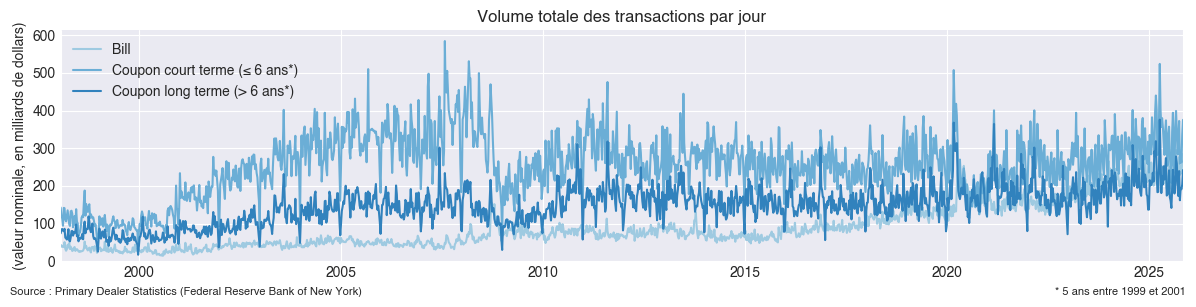

In [136]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator

plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

df1=df_pd.copy()

transaction_map = {
    "PDSUSGTBOT": "A transaction bill",
    "PDSUSGCS5LOT": "B transaction short coupon",
    "PDSUSGCS5MOT": "C transaction long coupon",
    "PDSUSGCS3LOT": "B transaction short coupon",
    "PDSUSGCS36OT": "B transaction short coupon",
    "PDSUSGCS611OT": "C transaction long coupon",
    "PDSUSGCSM11OT": "C transaction long coupon",
    "PDTRGS-EXTB": "A transaction bill",
    "PDTRGSC-L2": "B transaction short coupon",
    "PDTRGSC-G2L3": "B transaction short coupon",
    "PDTRGSC-G3L6": "B transaction short coupon",
    "PDTRGSC-G6L7": "C transaction long coupon",
    "PDTRGSC-G7L11": "C transaction long coupon",
    "PDTRGSC-G11": "C transaction long coupon",
    "PDTRGSC-G11L21": "C transaction long coupon",
    "PDTRGSC-G21": "C transaction long coupon"
}

df1["transaction_type"] = df1["Time Series"].map(transaction_map)
df1 = df1.pivot_table(
    index="As Of Date",
    columns="transaction_type",
    values="Value (millions)",
    aggfunc="sum"
)

df1.index.name = None

df1 = df1.rename(columns={
    "A transaction bill": "Bill",
    "B transaction short coupon": "Coupon court terme (≤ 6 ans*)",
    "C transaction long coupon": "Coupon long terme (> 6 ans*)"
})

fig, ax = plt.subplots(figsize=(12,3))
cmap = cm.get_cmap('tab20c')
colors = [cmap(2), cmap(1), cmap(0)]
df1.plot(ax=ax, color=colors)
ax.set_title("Volume totale des transactions par jour")
ax.set_ylabel("(valeur nominale, en milliards de dollars)")
ax.set_ylim(bottom=0)
ax.legend()
fig.text(0.01, -0.0, "Source : Primary Dealer Statistics (Federal Reserve Bank of New York)", ha="left", fontsize=8)
fig.text(0.99, -0.0, "* 5 ans entre 1999 et 2001", ha="right", fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_6588/2496373221.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


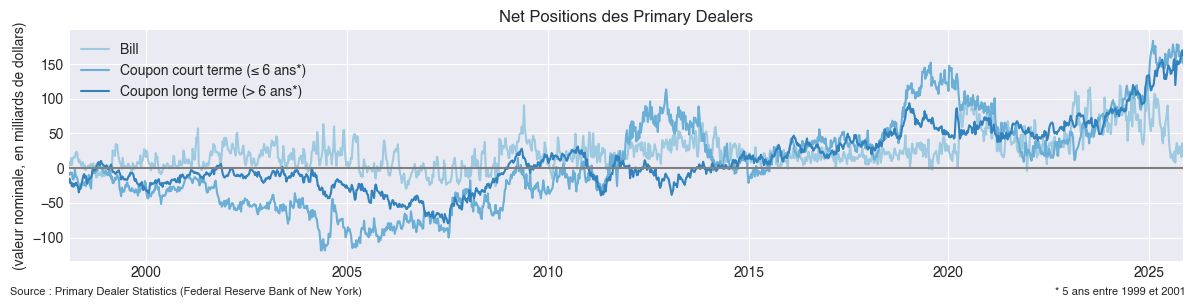

In [137]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator

plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

df1=df_pd.copy()

netposition_map = {
    "PDPUSGTBNOP": "A netpo bill",
    "PDPUSGCS5LNOP": "B netpo short coupon",
    "PDPUSGCS5MNOP": "C netpo long coupon",
    "PDPUSGCS3LNOP": "B netpo short coupon",
    "PDPUSGCS36NOP": "B netpo short coupon",
    "PDPUSGCS611NOP": "C netpo long coupon",
    "PDPUSGCSM11NOP": "C netpo long coupon",
    "PDPOSGS-B": "A netpo bill",
    "PDPOSGSC-L2": "B netpo short coupon",
    "PDPOSGSC-G2L3": "B netpo short coupon",
    "PDPOSGSC-G3L6": "B netpo short coupon",
    "PDPOSGSC-G6L7": "C netpo long coupon",
    "PDPOSGSC-G7L11": "C netpo long coupon",
    "PDPOSGSC-G11": "C netpo long coupon",
    "PDPOSGSC-G11L21": "C netpo long coupon",
    "PDPOSGSC-G21": "C netpo long coupon"
}

df1["netposition_type"] = df1["Time Series"].map(netposition_map)
df1 = df1.pivot_table(
    index="As Of Date",
    columns="netposition_type",
    values="Value (millions)",
    aggfunc="sum"
)

df1.index.name = None

df1 = df1.rename(columns={
    "A netpo bill": "Bill",
    "B netpo short coupon": "Coupon court terme (≤ 6 ans*)",
    "C netpo long coupon": "Coupon long terme (> 6 ans*)"
})

fig, ax = plt.subplots(figsize=(12,3))
cmap = cm.get_cmap('tab20c')
colors = [cmap(2), cmap(1), cmap(0)]
df1.plot(ax=ax, color=colors)
plt.axhline(0, color='gray')
ax.set_title("Net Positions des Primary Dealers")
ax.set_ylabel("(valeur nominale, en milliards de dollars)")
ax.legend()
fig.text(0.01, -0.0, "Source : Primary Dealer Statistics (Federal Reserve Bank of New York)", ha="left", fontsize=8)
fig.text(0.99, -0.0, "* 5 ans entre 1999 et 2001", ha="right", fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_6588/2824811427.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20c')


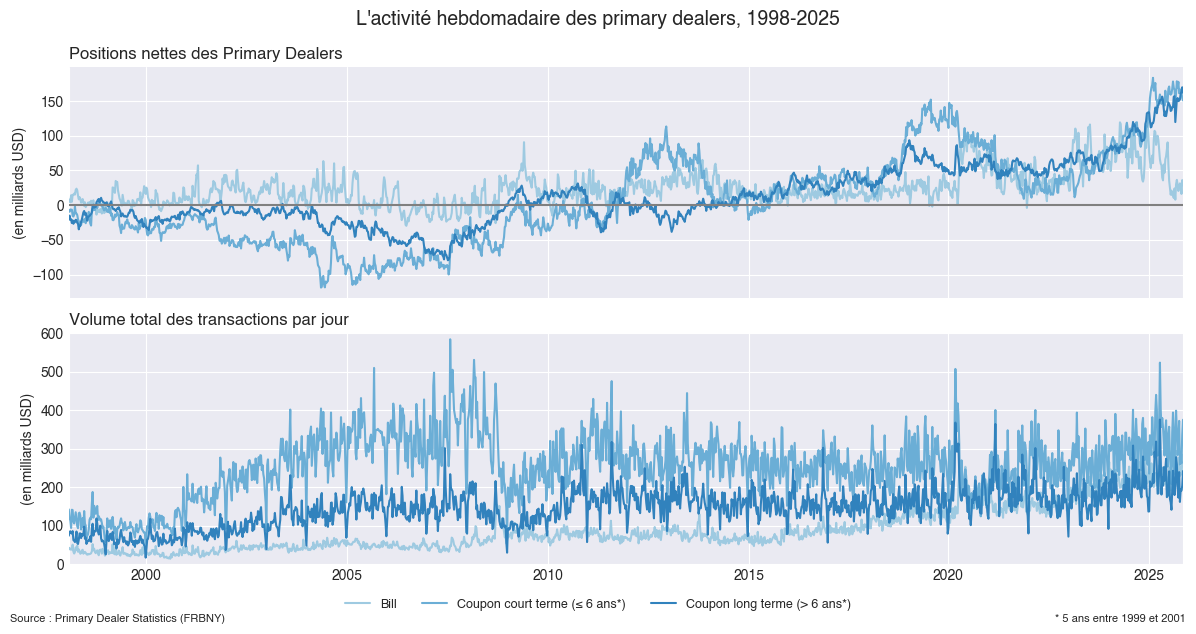

In [180]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

# ===============================
# 1 — Construire UN SEUL DATAFRAME propre
# ===============================

df_all = df_pd.copy()

# Mappings fusionnés
map_all = {
    # --- NETPO ---
    "PDPUSGTBNOP": ("netpo", "Bill"),
    "PDPUSGCS5LNOP": ("netpo", "Coupon court terme (≤ 6 ans*)"),
    "PDPUSGCS5MNOP": ("netpo", "Coupon long terme (> 6 ans*)"),
    "PDPUSGCS3LNOP": ("netpo", "Coupon court terme (≤ 6 ans*)"),
    "PDPUSGCS36NOP": ("netpo", "Coupon court terme (≤ 6 ans*)"),
    "PDPUSGCS611NOP": ("netpo", "Coupon long terme (> 6 ans*)"),
    "PDPUSGCSM11NOP": ("netpo", "Coupon long terme (> 6 ans*)"),
    "PDPOSGS-B": ("netpo", "Bill"),
    "PDPOSGSC-L2": ("netpo", "Coupon court terme (≤ 6 ans*)"),
    "PDPOSGSC-G2L3": ("netpo", "Coupon court terme (≤ 6 ans*)"),
    "PDPOSGSC-G3L6": ("netpo", "Coupon court terme (≤ 6 ans*)"),
    "PDPOSGSC-G6L7": ("netpo", "Coupon long terme (> 6 ans*)"),
    "PDPOSGSC-G7L11": ("netpo", "Coupon long terme (> 6 ans*)"),
    "PDPOSGSC-G11": ("netpo", "Coupon long terme (> 6 ans*)"),
    "PDPOSGSC-G11L21": ("netpo", "Coupon long terme (> 6 ans*)"),
    "PDPOSGSC-G21": ("netpo", "Coupon long terme (> 6 ans*)"),

    # --- TRANSACTIONS ---
    "PDSUSGTBOT": ("transaction", "Bill"),
    "PDSUSGCS5LOT": ("transaction", "Coupon court terme (≤ 6 ans*)"),
    "PDSUSGCS5MOT": ("transaction", "Coupon long terme (> 6 ans*)"),
    "PDSUSGCS3LOT": ("transaction", "Coupon court terme (≤ 6 ans*)"),
    "PDSUSGCS36OT": ("transaction", "Coupon court terme (≤ 6 ans*)"),
    "PDSUSGCS611OT": ("transaction", "Coupon long terme (> 6 ans*)"),
    "PDSUSGCSM11OT": ("transaction", "Coupon long terme (> 6 ans*)"),
    "PDTRGS-EXTB": ("transaction", "Bill"),
    "PDTRGSC-L2": ("transaction", "Coupon court terme (≤ 6 ans*)"),
    "PDTRGSC-G2L3": ("transaction", "Coupon court terme (≤ 6 ans*)"),
    "PDTRGSC-G3L6": ("transaction", "Coupon court terme (≤ 6 ans*)"),
    "PDTRGSC-G6L7": ("transaction", "Coupon long terme (> 6 ans*)"),
    "PDTRGSC-G7L11": ("transaction", "Coupon long terme (> 6 ans*)"),
    "PDTRGSC-G11": ("transaction", "Coupon long terme (> 6 ans*)"),
    "PDTRGSC-G11L21": ("transaction", "Coupon long terme (> 6 ans*)"),
    "PDTRGSC-G21": ("transaction", "Coupon long terme (> 6 ans*)")
}

# Appliquer le mapping
df_all["category"] = df_all["Time Series"].map(lambda x: map_all.get(x, (None, None))[0])
df_all["group"]    = df_all["Time Series"].map(lambda x: map_all.get(x, (None, None))[1])

# ===============================
# 2 — FIGURE À 2 GRAPHES
# ===============================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), sharex=True)
cmap = cm.get_cmap('tab20c')
colors = [cmap(2), cmap(1), cmap(0)]

# ===============================
# GRAPHE 1 — NET PO
# ===============================

df_net = (df_all[df_all["category"] == "netpo"]
          .pivot_table(index="As Of Date", columns="group",
                       values="Value (millions)", aggfunc="sum"))
df_net.index.name = None

df_net.plot(ax=ax1, color=colors)
ax1.axhline(0, color='gray')
ax1.set_title("Positions nettes des Primary Dealers", loc="left")
ax1.set_ylabel("(en milliards USD)")
ax1.get_legend().remove()

# ===============================
# GRAPHE 2 — TRANSACTIONS
# ===============================

df_tr = (df_all[df_all["category"] == "transaction"]
         .pivot_table(index="As Of Date", columns="group",
                      values="Value (millions)", aggfunc="sum"))
df_tr.index.name = None


df_tr.plot(ax=ax2, color=colors)
ax2.set_title("Volume total des transactions par jour", loc="left")
ax2.set_ylabel("(en milliards USD)")
ax2.set_ylim(bottom=0, top=600)
ax2.get_legend().remove()

# ===============================
# FOOTNOTES
# ===============================

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.04),   # décale légèrement sous la figure
    fontsize=9
)

fig.text(0.01, -0.04, "Source : Primary Dealer Statistics (FRBNY)", ha="left", fontsize=8)
fig.text(0.99, -0.04, "* 5 ans entre 1999 et 2001", ha="right", fontsize=8)

fig.suptitle("L'activité hebdomadaire des primary dealers, 1998-2025", fontsize=14)
plt.tight_layout()
plt.show()

## Émissions du Trésor (bills)

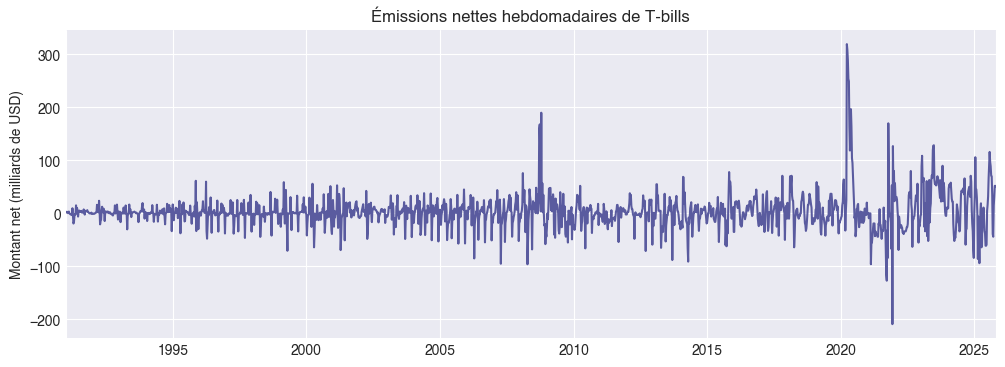

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Data/UST_Auctions_Bills.csv", parse_dates=["Issue Date", "Maturity Date"])

# Création des séries émission et remboursement
issues = (
    df.groupby(df["Issue Date"].dt.to_period("W").dt.start_time)["Total Accepted"]
      .sum()
)

redemptions = (
    df.groupby(df["Maturity Date"].dt.to_period("W").dt.start_time)["Total Accepted"]
      .sum()
      .mul(-1)  # on met les remboursements en négatif
)

# Alignement + calcul émission nette
net = (issues.add(redemptions, fill_value=0))/1e9

# Petite restriction de la plage (début et fin)
net = net.sort_index()
delta = pd.Timedelta(weeks=52)
start = net.index.min() + delta
end = net.index.max() - delta
net = net.loc[start:end]

fig, ax = plt.subplots(figsize=(12,4))
net.plot(ax=ax)

ax.set_title("Émissions nettes hebdomadaires de T-bills")
ax.set_ylabel("Montant net (milliards de USD)")

plt.show()


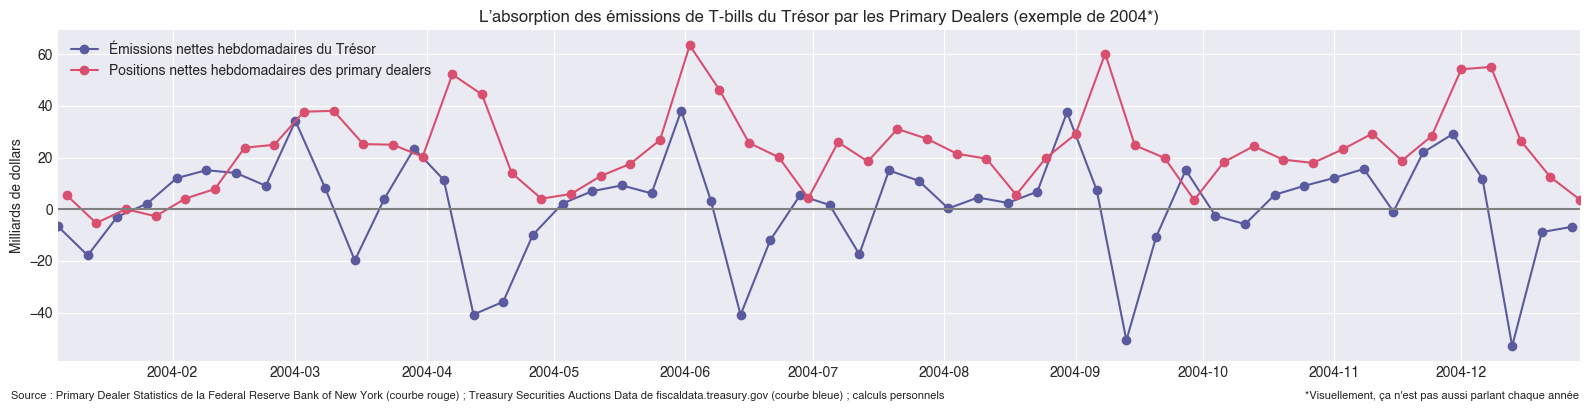

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Téléchargement et création de la série des émissions nette du Trésor
df = pd.read_csv("Data/UST_Auctions_Bills.csv", parse_dates=["Issue Date", "Maturity Date"])
issues = df.groupby(df["Issue Date"].dt.to_period("W").dt.start_time)["Total Accepted"].sum()
redemptions = df.groupby(df["Maturity Date"].dt.to_period("W").dt.start_time)["Total Accepted"].sum().mul(-1)
net = issues.add(redemptions, fill_value=0).sort_index()
net = net.loc[
    net.index.min() + pd.Timedelta(weeks=52) :
    net.index.max() - pd.Timedelta(weeks=52)
]/1e9

# Extraction de la position des dealers en T-bills (df créé plus haut)
billpos = df1["Bill"]
billpos.index = pd.to_datetime(billpos.index)
billpos = billpos.sort_index()

# Fenêtre de zoom choisie
zoom_start = pd.to_datetime("2004-01-01")
zoom_end   = zoom_start + pd.Timedelta(weeks=52)
net = net.loc[zoom_start:zoom_end]
billpos = billpos.loc[zoom_start:zoom_end]

# Plot
fig, ax = plt.subplots(figsize=(16,4))
ax.plot(net.index, net.values, marker='o', label="Émissions nettes hebdomadaires du Trésor")
ax.plot(billpos.index, billpos.values, marker='o', label="Positions nettes hebdomadaires des primary dealers")
ax.axhline(0, color='gray')
ax.set_xmargin(0)
ax.set_title("L’absorption des émissions de T-bills du Trésor par les Primary Dealers (exemple de 2004*)")
ax.set_ylabel("Milliards de dollars")
ax.legend()
fig.text(0.01, -0.01, "Source : Primary Dealer Statistics de la Federal Reserve Bank of New York (courbe rouge) ; Treasury Securities Auctions Data de fiscaldata.treasury.gov (courbe bleue) ; calculs personnels", ha="left", fontsize=8)
fig.text(0.99, -0.01, "*Visuellement, ça n'est pas aussi parlant chaque année", ha="right", fontsize=8)
plt.tight_layout()
plt.show()